In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import mlflow
import mlflow.sklearn
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

# === Load dataset ===
WIN_PATH = "/Users/aleksandar.stojanovic/Downloads/ai_system/ml_scripts/data/processed/win_model_data.parquet"
df = pd.read_parquet(WIN_PATH)
X = np.vstack(df["features"].values)
y = df["target"].values  # 0 = WIN_X, 1 = WIN_O, 2 = DRAW

# === Train/Test split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# === Confusion Matrix Helper ===
def log_confusion_matrix(cm, run_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {run_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        fig.savefig(tmp.name)
        mlflow.log_artifact(tmp.name, artifact_path="confusion_matrices")

/Users/aleksandar.stojanovic/Downloads/ai_system/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksandar.stojanovic/Downloads/ai_system/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksandar.stojanovic/Downloads/ai_system/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

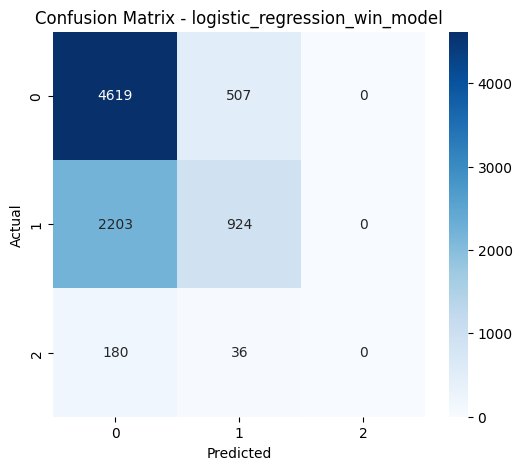

In [14]:
with mlflow.start_run(run_name="logistic_regression_win_model"):
    start_time = time.time()
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log metrics ===
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # Per-class metrics
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    # Macro/weighted
    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # Confusion matrix
    log_confusion_matrix(cm, "logistic_regression_win_model")

    # Log model
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_logreg")


2025/12/14 11:44:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'win_model_random_forest'.
Created version '1' of model 'win_model_random_forest'.


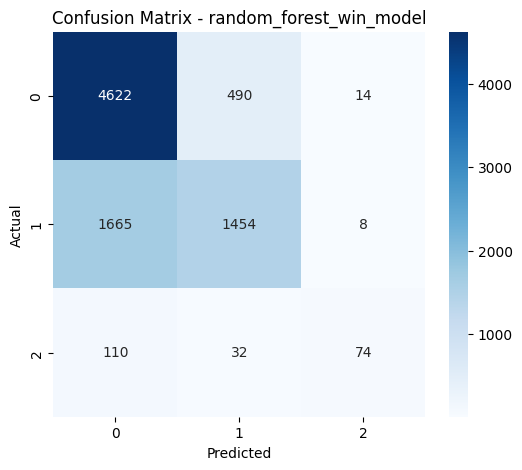

In [15]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="random_forest_win_model"):
    start_time = time.time()
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log class-level metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Confusion Matrix ===
    log_confusion_matrix(cm, "random_forest_win_model")

    # === Log model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_random_forest")


/Users/aleksandar.stojanovic/Downloads/ai_system/.venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:45:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2025/12/14 11:45:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'win_model_xgboost'.
Created version '1' of model 'win_model_xgboost'.


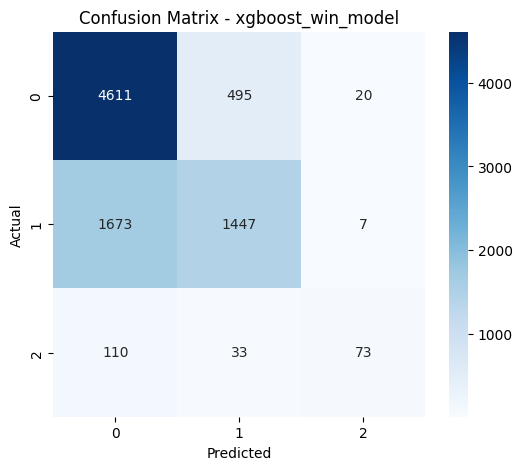

In [17]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="xgboost_win_model"):
    start_time = time.time()
    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Log confusion matrix ===
    log_confusion_matrix(cm, "xgboost_win_model")

    # === Log model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_xgboost")


2025/12/14 11:46:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'win_model_mlp_64x64'.
Created version '1' of model 'win_model_mlp_64x64'.


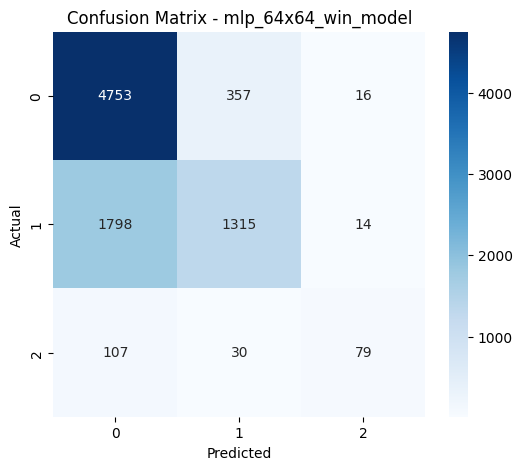

In [18]:
from sklearn.neural_network import MLPClassifier

with mlflow.start_run(run_name="mlp_64x64_win_model"):
    start_time = time.time()
    model = MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "MLPClassifier_64x64")
    mlflow.log_param("layers", "64x64")
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log class metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Log confusion matrix ===
    log_confusion_matrix(cm, "mlp_64x64_win_model")

    # === Save model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_mlp_64x64")


2025/12/14 11:46:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'win_model_mlp_128x128'.
Created version '1' of model 'win_model_mlp_128x128'.


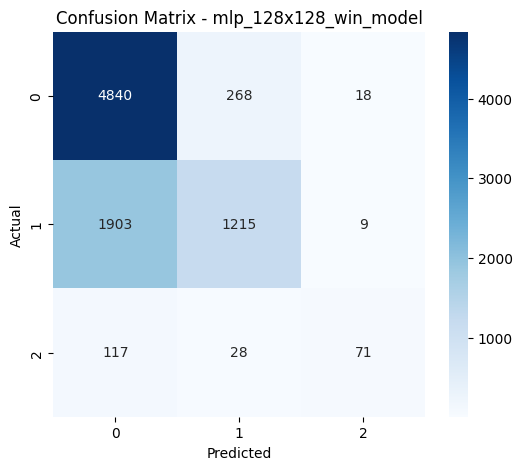

In [19]:
with mlflow.start_run(run_name="mlp_128x128_win_model"):
    start_time = time.time()
    model = MLPClassifier(
        hidden_layer_sizes=(128, 128),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "MLPClassifier_128x128")
    mlflow.log_param("layers", "128x128")
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log per-class metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Log confusion matrix ===
    log_confusion_matrix(cm, "mlp_128x128_win_model")

    # === Log model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_mlp_128x128")


2025/12/14 11:48:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'win_model_catboost'.
Created version '1' of model 'win_model_catboost'.


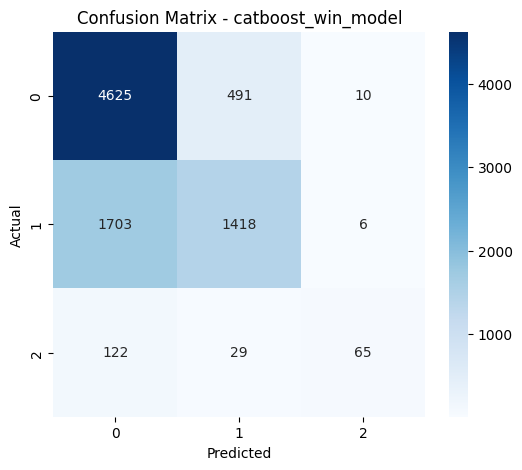

In [21]:
from catboost import CatBoostClassifier

with mlflow.start_run(run_name="catboost_win_model"):
    start_time = time.time()
    model = CatBoostClassifier(
        iterations=100,
        depth=6,
        learning_rate=0.1,
        verbose=0,
        random_seed=42
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "CatBoost")
    mlflow.log_param("iterations", 100)
    mlflow.log_param("depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log per-class metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Log confusion matrix ===
    log_confusion_matrix(cm, "catboost_win_model")

    # === Log model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_catboost")
